In [74]:
import pandas as pd
import os
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from collections import defaultdict
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from collections import Counter

In [24]:

file1 = "Multisource_investors.csv" 
file2 = "investmentss.csv"

# Merging the first two files
def load_and_merge_csv(file1, file2, merge_type='outer'):
    """
    Load and merge two CSV files
    
    Parameters:
    file1 (str): Path to first CSV file
    file2 (str): Path to second CSV file
    merge_type (str): Type of merge - 'inner', 'outer', 'left', 'right'
    """
    try:
        # Load the files
        df1 = pd.read_csv(file1)
        df2 = pd.read_csv(file2)
        
        print(f"File 1 shape: {df1.shape}")
        print(f"File 2 shape: {df2.shape}")
        print(f"File 1 columns: {list(df1.columns)}")
        print(f"File 2 columns: {list(df2.columns)}")
        
        # Find common columns for merging
        common_cols = list(set(df1.columns) & set(df2.columns))
        print(f"Common columns: {common_cols}")
        
        if common_cols:
            # Merge on common columns
            merged_df = pd.merge(df1, df2, on=common_cols, how=merge_type)
        else:
            # Concatenate (if no common columns)
            merged_df = pd.concat([df1, df2], ignore_index=True)
            
        print(f"Merged dataframe shape: {merged_df.shape}")
        return merged_df
        
        
    except Exception as e:
        print(f"Error: {e}")
        return None

            
        print(f"Merged dataframe shape: {merged_df.shape}")
        return merged_df
        
# function call and results storage
merged_data = load_and_merge_csv(file1, file2)

# result display
if merged_data is not None:
    print("\nFirst 5 rows of merged data:")
    print(merged_data.head())

File 1 shape: (1563, 6)
File 2 shape: (61403, 3)
File 1 columns: ['investor_id', 'name', 'funded_at', 'raised_amount', 'raised_currency_code', 'source_description']
File 2 columns: ['funding_round_id', 'funded_object_id', 'investor_id']
Common columns: ['investor_id']
Merged dataframe shape: (106776, 8)

First 5 rows of merged data:
  investor_id               name  funded_at  raised_amount  \
0         f:1  Greylock Fund XIV  9/10/2013   1.000000e+09   
1         f:1  Greylock Fund XIV  9/10/2013   1.000000e+09   
2         f:1  Greylock Fund XIV  9/10/2013   1.000000e+09   
3         f:1  Greylock Fund XIV  9/10/2013   1.000000e+09   
4         f:1  Greylock Fund XIV  9/10/2013   1.000000e+09   

  raised_currency_code                                 source_description  \
0                  USD  Greylock Partners raises $1 billion for new ve...   
1                  USD  Greylock Partners raises $1 billion for new ve...   
2                  USD  Greylock Partners raises $1 billion f

In [25]:
df = pd.DataFrame(merged_data)

# The merged data is now saved to CSV to create a new file
df.to_csv('output.csv', index=False)
print("Data successfully saved to output.csv")

Data successfully saved to output.csv


In [26]:
file1 = "output.csv" 
file2 = "office loc.csv"

# the new merged data file is now merged with the third file.
def load_and_merge_csv(file1, file2, merge_type='outer'):
    """
    Load and merge two CSV files
    
    Parameters:
    file1 (str): Path to first CSV file
    file2 (str): Path to second CSV file
    merge_type (str): Type of merge - 'inner', 'outer', 'left', 'right'
    """
    try:
        # Load the files
        df1 = pd.read_csv(file1)
        df2 = pd.read_csv(file2)
        
        print(f"File 1 shape: {df1.shape}")
        print(f"File 2 shape: {df2.shape}")
        print(f"File 1 columns: {list(df1.columns)}")
        print(f"File 2 columns: {list(df2.columns)}")
        
        # Find common columns for merging
        common_cols = list(set(df1.columns) & set(df2.columns))
        print(f"Common columns: {common_cols}")
        
        if common_cols:
            # Merge on common columns
            merged_df1 = pd.merge(df1, df2, on=common_cols, how=merge_type)
        else:
            # Concatenate if no common columns
            merged_df1 = pd.concat([df1, df2], ignore_index=True)
            
        print(f"Merged dataframe shape: {merged_df1.shape}")
        return merged_df1
        
        
    except Exception as e:
        print(f"Error: {e}")
        return None

            
        print(f"Merged dataframe shape: {merged_df1.shape}")
        return merged_df1
        
# function call and result storage
merged_data1 = load_and_merge_csv(file1, file2)

# result display
if merged_data1 is not None:
    print("\nFirst 5 rows of merged data:")
    print(merged_data1.head())

File 1 shape: (106776, 8)
File 2 shape: (112718, 3)
File 1 columns: ['investor_id', 'name', 'funded_at', 'raised_amount', 'raised_currency_code', 'source_description', 'funding_round_id', 'funded_object_id']
File 2 columns: ['id', 'funded_object_id', 'country_code']
Common columns: ['funded_object_id']
Merged dataframe shape: (228903, 10)

First 5 rows of merged data:
  investor_id                name  funded_at  raised_amount  \
0       f:262  DAG Ventures IV-QP  2/22/2010    451825000.0   
1       f:262  DAG Ventures IV-QP  2/22/2010    451825000.0   
2       f:262     DAG Ventures IV  2/22/2010     47750000.0   
3       f:262     DAG Ventures IV  2/22/2010     47750000.0   
4       f:262   DAG Ventures V-QP  6/24/2011    500000000.0   

  raised_currency_code                             source_description  \
0                  USD                                          SEC D   
1                  USD                                          SEC D   
2                  USD         

In [27]:
df = pd.DataFrame(merged_data1)

# The merged data is now saved to CSV to create a new file
df.to_csv('output1.csv', index=False)
print("Data successfully saved to output1.csv")

Data successfully saved to output1.csv


In [28]:
file1 = "output1.csv" 
file2 = "company names.csv"

# the new merged data file is now merged with the third file.
def load_and_merge_csv(file1, file2, merge_type='outer'):
    """
    Load and merge two CSV files
    
    Parameters:
    file1 (str): Path to first CSV file
    file2 (str): Path to second CSV file
    merge_type (str): Type of merge - 'inner', 'outer', 'left', 'right'
    """
    try:
        # Load the files
        df1 = pd.read_csv(file1)
        df2 = pd.read_csv(file2)
        
        print(f"File 1 shape: {df1.shape}")
        print(f"File 2 shape: {df2.shape}")
        print(f"File 1 columns: {list(df1.columns)}")
        print(f"File 2 columns: {list(df2.columns)}")
        
        # Find common columns for merging
        common_cols = list(set(df1.columns) & set(df2.columns))
        print(f"Common columns: {common_cols}")
        
        if common_cols:
            # Merge on common columns
            merged_df2 = pd.merge(df1, df2, on=common_cols, how=merge_type)
        else:
            # Concatenate if no common columns
            merged_df2 = pd.concat([df1, df2], ignore_index=True)
            
        print(f"Merged dataframe shape: {merged_df2.shape}")
        return merged_df2
        
        
    except Exception as e:
        print(f"Error: {e}")
        return None

            
        print(f"Merged dataframe shape: {merged_df2.shape}")
        return merged_df2
        
# function call and result storage
merged_data2 = load_and_merge_csv(file1, file2)

# Display the result
if merged_data2 is not None:
    print("\nFirst 5 rows of merged data:")
    print(merged_data2.head())

C:\Users\Sandra-Paluku\AppData\Local\Temp\ipykernel_23976\3169234680.py:17: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(file2)


File 1 shape: (228903, 10)
File 2 shape: (462651, 3)
File 1 columns: ['investor_id', 'name', 'funded_at', 'raised_amount', 'raised_currency_code', 'source_description', 'funding_round_id', 'funded_object_id', 'id', 'country_code']
File 2 columns: ['funded_object_id', 'Company_name', 'category_code']
Common columns: ['funded_object_id']
Merged dataframe shape: (595567, 12)

First 5 rows of merged data:
  investor_id                name  funded_at  raised_amount  \
0       f:262  DAG Ventures IV-QP  2/22/2010    451825000.0   
1       f:262  DAG Ventures IV-QP  2/22/2010    451825000.0   
2       f:262     DAG Ventures IV  2/22/2010     47750000.0   
3       f:262     DAG Ventures IV  2/22/2010     47750000.0   
4       f:262   DAG Ventures V-QP  6/24/2011    500000000.0   

  raised_currency_code                             source_description  \
0                  USD                                          SEC D   
1                  USD                                          SEC D 

In [29]:
df = pd.DataFrame(merged_data2)

# The 2nd merged data is now saved to CSV to create a new file
df.to_csv('output2.csv', index=False)
print("Data successfully saved to output2.csv")

Data successfully saved to output2.csv


In [30]:
# Data cleaning and preprocessing. The data being cleaned here is the output3 data, the 2nd merged data.
input_file = "output2.csv"

def clean_investor_data(input_file, output_file):
    """
    Comprehensive data cleaning for investor data before ID assignment.
    """
    
    print("Loading data...")
    df = pd.read_csv(input_file)
    original_count = len(df)
    print(f"Original dataset: {original_count} rows, {len(df.columns)} columns")
    
    # 1. BASIC DATA INSPECTION
    print("\n" + "="*50)
    print("1. DATA INSPECTION")
    print("="*50)
    
    print("Columns:", list(df.columns))
    print(f"Missing values per column:")
    missing_info = df.isnull().sum()
    for col, missing in missing_info.items():
        if missing > 0:
            print(f"  {col}: {missing} ({missing/len(df)*100:.1f}%)")
    
    # 2. CLEAN INVESTOR NAMES
    print("\n" + "="*50)
    print("2. CLEANING INVESTOR NAMES")
    print("="*50)
    
    def clean_name(name):
        if pd.isna(name):
            return name
        
        # Convert to string and strip whitespace
        name = str(name).strip()
        
        # Remove extra whitespace between words
        name = re.sub(r'\s+', ' ', name)
        
        # Remove common suffixes that might cause duplicates
        suffixes_to_standardize = {
            r'\s+(Inc\.?|LLC\.?|Ltd\.?|LP\.?|LLP\.?|Corp\.?|Corporation)$': '',
            r'\s+&\s+(Co\.?|Company)$': ' & Co',
            r'\s+(Ventures?|Capital|Partners?|Investments?)$': lambda m: ' ' + m.group(1).rstrip('s') + 's' if m.group(1).lower() in ['venture', 'partner'] else ' ' + m.group(1)
        }
        
        for pattern, replacement in suffixes_to_standardize.items():
            if callable(replacement):
                name = re.sub(pattern, replacement, name, flags=re.IGNORECASE)
            else:
                name = re.sub(pattern, replacement, name, flags=re.IGNORECASE)
        
        return name
    
    # Apply name cleaning
    df['name'] = df['name'].apply(clean_name)
    
    # 3. FIND AND HANDLE DUPLICATES
    print("\n" + "="*50)
    print("3. DUPLICATE DETECTION & HANDLING")
    print("="*50)
    
    # Check for exact duplicates
    exact_duplicates = df.duplicated(subset=['name'], keep=False)
    if exact_duplicates.any():
        print(f"Exact duplicates found: {exact_duplicates.sum()} rows")
        duplicate_names = df[exact_duplicates]['name'].value_counts()
        print("Top duplicate names:")
        for name, count in duplicate_names.head(10).items():
            print(f"  '{name}': {count} times")
    
    # Check for similar names (fuzzy matching)
    print("\nChecking for similar names...")
    name_counts = df['name'].value_counts()
    
    # Find potential fuzzy duplicates
    potential_duplicates = []
    names_list = df['name'].dropna().unique()
    
    for i, name1 in enumerate(names_list):
        for name2 in names_list[i+1:]:
            if similar_names(name1, name2):
                potential_duplicates.append((name1, name2))
    
    if potential_duplicates:
        print(f"Potential similar names found: {len(potential_duplicates)} pairs")
        print("First 10 pairs (review these manually):")
        for name1, name2 in potential_duplicates[:10]:
            print(f"  '{name1}' <-> '{name2}'")
    
    #This removes exact duplicates but keeps first occurrence
    df_cleaned = df.drop_duplicates(subset=['name'], keep='first')
    removed_duplicates = len(df) - len(df_cleaned)
    if removed_duplicates > 0:
        print(f"Removed {removed_duplicates} exact duplicate rows")
    
    # 4. HANDLE MISSING VALUES
    print("\n" + "="*50)
    print("4. HANDLING MISSING VALUES")
    print("="*50)
    
    # Remove rows with missing investor names
    missing_names = df_cleaned['name'].isnull().sum()
    if missing_names > 0:
        df_cleaned = df_cleaned.dropna(subset=['name'])
        print(f"Removed {missing_names} rows with missing investor names")
    
    # Handle missing values in other columns
    for col in df_cleaned.columns:
        if col != 'name':
            missing_count = df_cleaned[col].isnull().sum()
            if missing_count > 0:
                # filled numeric columns with medial value.
                if df_cleaned[col].dtype in ['int64', 'float64']:
                    median_val = df_cleaned[col].median()
                    df_cleaned[col] = df_cleaned[col].fillna(median_val)
                    print(f"Filled {missing_count} missing values in '{col}' with median: {median_val}")
                # Filled text columns with 'Unknown' so the results don't get skewed
                else:
                    df_cleaned[col] = df_cleaned[col].fillna('Unknown')
                    print(f"Filled {missing_count} missing values in '{col}' with 'Unknown'")
    
    # 5. DATA VALIDATION
    print("\n" + "="*50)
    print("5. DATA VALIDATION")
    print("="*50)
    
    # Check for empty names
    empty_names = df_cleaned['name'].str.strip().eq('').sum()
    if empty_names > 0:
        df_cleaned = df_cleaned[df_cleaned['name'].str.strip() != '']
        print(f"Removed {empty_names} rows with empty names")
    
    # Checking for invalid very short names 
    short_names = df_cleaned['name'].str.len() < 2
    if short_names.sum() > 0:
        print(f"Found {short_names.sum()} names with less than 2 characters:")
        print(df_cleaned[short_names]['name'].tolist())
       
    
    # 6. FINAL CLEANUP
    print("\n" + "="*50)
    print("6. FINAL CLEANUP")
    print("="*50)
    
    # Reset index
    df_cleaned = df_cleaned.reset_index(drop=True)
    
    # Sort by name for easier review
    df_cleaned = df_cleaned.sort_values('name').reset_index(drop=True)
    
    # Save cleaned data
    df_cleaned.to_csv(output_file, index=False)
    
    # SUMMARY
    print("\n" + "="*50)
    print("CLEANING SUMMARY")
    print("="*50)
    print(f"Original rows: {original_count}")
    print(f"Final rows: {len(df_cleaned)}")
    print(f"Rows removed: {original_count - len(df_cleaned)}")
    print(f"Unique investors: {df_cleaned['name'].nunique()}")
    print(f"Cleaned data saved to: {output_file}")
    
    return df_cleaned

def similar_names(name1, name2, threshold=0.8):
    """
    Simple similarity check for names.
    You can make this more sophisticated with libraries like fuzzywuzzy.
    """
    if pd.isna(name1) or pd.isna(name2):
        return False
    
    name1, name2 = str(name1).lower(), str(name2).lower()
    
    # Checks if one name is contained in another
    if name1 in name2 or name2 in name1:
        return True
    
    # Checks if they share most words
    words1 = set(name1.split())
    words2 = set(name2.split())
    
    if len(words1) == 0 or len(words2) == 0:
        return False
    
    intersection = len(words1 & words2)
    union = len(words1 | words2)
    
    return intersection / union >= threshold

def manual_duplicate_resolver(df, output_file):
    """
    Helper function to manually resolve potential duplicates.
    Call this after the main cleaning if you want to review similar names.
    """
    
    print("MANUAL DUPLICATE RESOLUTION")
    print("="*50)
    print("This will help you manually resolve potential duplicate investors.")
    print("You'll be shown pairs of similar names and can choose to merge them.")
    
    # Find potential duplicates again
    names_list = df['name'].dropna().unique()
    potential_duplicates = []
    
    for i, name1 in enumerate(names_list):
        for name2 in names_list[i+1:]:
            if similar_names(name1, name2):
                potential_duplicates.append((name1, name2))
    
    if not potential_duplicates:
        print("No potential duplicates found.")
        return df
    
    print(f"Found {len(potential_duplicates)} potential duplicate pairs.")
    
    return df

# function call
if __name__ == "__main__":
    cleaned_df = clean_investor_data(
        'output2.csv',           # this is the original merged file
        'output2_cleaned.csv'    # and this is the cleaned output file
    )
    

Loading data...


C:\Users\Sandra-Paluku\AppData\Local\Temp\ipykernel_23976\2930467386.py:10: DtypeWarning: Columns (0,1,2,4,5,9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


Original dataset: 595567 rows, 12 columns

1. DATA INSPECTION
Columns: ['investor_id', 'name', 'funded_at', 'raised_amount', 'raised_currency_code', 'source_description', 'funding_round_id', 'funded_object_id', 'id', 'country_code', 'Company_name', 'category_code']
Missing values per column:
  investor_id: 459030 (77.1%)
  name: 501484 (84.2%)
  funded_at: 504378 (84.7%)
  raised_amount: 501484 (84.2%)
  raised_currency_code: 501484 (84.2%)
  source_description: 517382 (86.9%)
  funding_round_id: 459336 (77.1%)
  funded_object_id: 306 (0.1%)
  id: 370152 (62.2%)
  country_code: 370152 (62.2%)
  Company_name: 726 (0.1%)
  category_code: 346150 (58.1%)

2. CLEANING INVESTOR NAMES

3. DUPLICATE DETECTION & HANDLING
Exact duplicates found: 595227 rows
Top duplicate names:
  'Fund III': 2703 times
  'Fund II': 2439 times
  'Fund IV': 2119 times
  'Fund VI': 1583 times
  'Fund I': 1261 times
  'Fund V': 1205 times
  'Fund VII': 1063 times
  'Fund IX': 932 times
  'Fund XIV': 916 times
  'Seq

In [56]:
#data preprocessing
#drop unneeded columns
df = pd.read_csv("output2_cleaned.csv")
columns_to_drop = ['investor_id', 'funded_at', 'funding_round_id', 'source_description', 'funded_object_id', 'id']
df = df.drop(columns=columns_to_drop)

# Remove digits from the 'name' column 
df['name'] = df['name'].str.replace(r'\d+', '', regex=True)

# Saved the updated DataFrame to a new CSV
df.to_csv("output3_cleaned.csv", index=False)
print (df.head)

<bound method NDFrame.head of                                  name  raised_amount raised_currency_code  \
0                  $M HealthCare Fund    550000000.0                  USD   
1                         Ventures I,            0.0                  USD   
2                        Ventures II,            0.0                  USD   
3                     "Consumer" Fund    300000000.0                  USD   
4                      Jumpstart Fund       120000.0                  USD   
...                               ...            ...                  ...   
1312               second growth fund    255000000.0                  USD   
1313      second venture capital fund      6000000.0                  USD   
1314                        seed fund     30000000.0                  EUR   
1315  uardian Capital Partners Fund I     50000000.0                  USD   
1316                     venture fund    365000000.0                  USD   

     country_code        Company_name categor

In [4]:
pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [5]:
import selenium
print(selenium.__version__)

4.33.0


Error: Message: 
Stacktrace:
	GetHandleVerifier [0x0x7ff649c2cda5+78885]
	GetHandleVerifier [0x0x7ff649c2ce00+78976]
	(No symbol) [0x0x7ff6499e9bca]
	(No symbol) [0x0x7ff649a40766]
	(No symbol) [0x0x7ff649a40a1c]
	(No symbol) [0x0x7ff649a94467]
	(No symbol) [0x0x7ff649a68bcf]
	(No symbol) [0x0x7ff649a9122f]
	(No symbol) [0x0x7ff649a68963]
	(No symbol) [0x0x7ff649a316b1]
	(No symbol) [0x0x7ff649a32443]
	GetHandleVerifier [0x0x7ff649f04eed+3061101]
	GetHandleVerifier [0x0x7ff649eff33d+3037629]
	GetHandleVerifier [0x0x7ff649f1e592+3165202]
	GetHandleVerifier [0x0x7ff649c4730e+186766]
	GetHandleVerifier [0x0x7ff649c4eb3f+217535]
	GetHandleVerifier [0x0x7ff649c359b4+114740]
	GetHandleVerifier [0x0x7ff649c35b69+115177]
	GetHandleVerifier [0x0x7ff649c1c368+10728]
	BaseThreadInitThunk [0x0x7ff9ab58e8d7+23]
	RtlUserThreadStart [0x0x7ff9acbdc34c+44]



In [80]:
class InvestorStartupRecommender:
    def __init__(self, data_path, n_recommendations=20):
        """
        Initialize the recommender system.
        
        Parameters:
        - data_path: Path to the CSV file containing investor-startup data
        - n_recommendations: Number of startups to recommend (default: 20)
        """
        self.n_recommendations = n_recommendations
        self.load_and_validate_data(data_path)
        self.preprocess_data()
        self.build_recommender()
    
    def load_and_validate_data(self, data_path):
        """Load and validate the input data structure"""
        try:
            self.data = pd.read_csv(data_path)
            
            # Check for required columns
            required_columns = {'name', 'raised_amount', 'raised_currency_code', 
                              'country_code', 'Company_name', 'category_code'}
            
            if not required_columns.issubset(self.data.columns):
                missing = required_columns - set(self.data.columns)
                raise ValueError(f"Missing required columns: {missing}")
                
            self.original_data = self.data.copy()
            
        except Exception as e:
            raise ValueError(f"Data loading failed: {str(e)}")
    
    def preprocess_data(self):
        """Preprocess the data for the recommendation system."""
        # clean copy of the data created to avoid chained assignment warnings
        data_clean = self.data.dropna(subset=['Company_name', 'name']).copy()
        
        # Handle missing values 
        data_clean['raised_amount'] = pd.to_numeric(data_clean['raised_amount'], errors='coerce')
        median_amount = data_clean['raised_amount'].median()
        data_clean['raised_amount'] = data_clean['raised_amount'].fillna(median_amount)
        data_clean['country_code'] = data_clean['country_code'].fillna('Unknown')
        data_clean['category_code'] = data_clean['category_code'].fillna('other')
        
        # Standardize category strings
        data_clean['category_code'] = (
            data_clean['category_code']
            .str.lower()
            .str.strip()
            .str.replace(r'[^a-z0-9\s]', '', regex=True)
        )
        
        # Label encoding for countries
        self.country_encoder = LabelEncoder()
        data_clean['country_code_encoded'] = self.country_encoder.fit_transform(
            data_clean['country_code']
        )
        
        # Update the main dataframe
        self.data = data_clean
        
        # Create investor profiles
        self.investor_profiles = (
            self.data
            .groupby('name')
            .agg({
                'raised_amount': 'mean',
                'country_code_encoded': lambda x: x.mode()[0] if len(x.mode()) > 0 else 0,
                'category_code': lambda x: ' '.join(x.astype(str))
            })
            .reset_index()
        )
        
        # Create startup profiles with fallback values
        self.startup_profiles = (
            self.data
            .groupby('Company_name')
            .agg({
                'raised_amount': 'mean',
                'country_code_encoded': lambda x: x.mode()[0] if len(x.mode()) > 0 else 0,
                'category_code': lambda x: ' '.join(x.astype(str)),
                'raised_currency_code': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'USD'
            })
            .reset_index()
        )
        
        # Create a lookup dictionary for startup details
        self.startup_details = (
            self.data
            .groupby('Company_name')
            .first()
            .to_dict('index')
        )
    
    def build_recommender(self):
        """Build the recommendation model using TF-IDF."""
        # Custom tokenizer function
        def tokenizer(text):
            return text.split()
        
        # TF-IDF vectorizer for categories with custom tokenizer
        self.tfidf = TfidfVectorizer(
            tokenizer=tokenizer,
            lowercase=False,
            min_df=2,  # Ignore categories that appear in only 1 startup
            token_pattern=None  # Explicitly set to None since we're using tokenizer
        )
        
        # Fit TF-IDF on all categories
        all_categories = pd.concat([
            self.investor_profiles['category_code'],
            self.startup_profiles['category_code']
        ])
        self.tfidf.fit(all_categories)
        
        # Transform startup categories
        startup_tfidf = self.tfidf.transform(self.startup_profiles['category_code'])
        
        # Scale numerical features
        self.scaler = StandardScaler()
        scaled_amount = self.scaler.fit_transform(
            self.startup_profiles[['raised_amount']]
        )
        
        # Combine features
        self.startup_features = np.hstack([
            scaled_amount,
            self.startup_profiles['country_code_encoded'].values.reshape(-1, 1),
            startup_tfidf.toarray()
        ])
    
    def recommend_startups(self, investor_name):
        """
        Recommend startups for a given investor.
        
        Returns:
        - DataFrame with columns: Company_name, category, country, 
          avg_raised_amount, currency, similarity_score
        """
        # Validate investor exists
        if investor_name not in self.investor_profiles['name'].values:
            similar_names = self.get_similar_names(investor_name)
            raise ValueError(f"Investor '{investor_name}' not found. Similar names: {similar_names[:5]}")
        
        # Get investor profile
        investor_profile = self.investor_profiles[
            self.investor_profiles['name'] == investor_name
        ]
        
        # Transform features
        investor_tfidf = self.tfidf.transform(investor_profile['category_code'])
        scaled_amount = self.scaler.transform(
            investor_profile[['raised_amount']]
        )
        
        # Create investor feature vector
        investor_features = np.hstack([
            scaled_amount,
            investor_profile['country_code_encoded'].values.reshape(-1, 1),
            investor_tfidf.toarray()
        ])
        
        # Calculate similarities
        similarities = cosine_similarity(investor_features, self.startup_features)
        similar_indices = np.argsort(similarities[0])[::-1][:self.n_recommendations]
        
        # Prepare recommendations
        recommendations = []
        for idx in similar_indices:
            startup_name = self.startup_profiles.iloc[idx]['Company_name']
            details = self.startup_details.get(startup_name, {})
            
            rec = {
                'Company_name': startup_name,
                'category': self.startup_profiles.iloc[idx]['category_code'].split()[0],
                'country': self.country_encoder.inverse_transform(
                    [self.startup_profiles.iloc[idx]['country_code_encoded']]
                )[0],
                'avg_raised_amount': self.startup_profiles.iloc[idx]['raised_amount'],
                'currency': self.startup_profiles.iloc[idx]['raised_currency_code'],
                'similarity_score': similarities[0][idx]
            }
            
            # Fallback to original data if needed
            for field in ['category', 'country', 'currency']:
                if pd.isna(rec[field]) or rec[field] == '':
                    rec[field] = details.get(field.lower() + '_code', 'Unknown')
            
            recommendations.append(rec)
        
        return pd.DataFrame(recommendations).sort_values('similarity_score', ascending=False)
    
    def get_similar_names(self, name, n=5):
        """Find similar investor names for helpful error messages"""
        from difflib import get_close_matches
        return get_close_matches(
            name, 
            self.investor_profiles['name'].unique(), 
            n=n, 
            cutoff=0.6
        )


if __name__ == "__main__":
    try:
        # Initialize with data file
        recommender = InvestorStartupRecommender('output3_cleaned.csv')
        
        # Example query
        investor_name = "Sequoia India III"  # I tried with three examples of investor names and randomly kept 1
        recommendations = recommender.recommend_startups(investor_name)
        
        print(f"\nTop {len(recommendations)} recommendations for {investor_name}:")
        print(recommendations[['Company_name', 'category', 'country', 
                             'avg_raised_amount', 'similarity_score']].head())
        
        # save recommendations to CSV
        recommendations.to_csv(f"{investor_name}_recommendations.csv", index=False)
        
    except Exception as e:
        print(f"Error: {str(e)}")


Top 20 recommendations for Sequoia India III:
   Company_name category country  avg_raised_amount  similarity_score
0           Fon   mobile     ESP        380297500.0          0.999984
1           C4M   mobile     FRA         57500067.5          0.999857
2  mobilePeople   mobile     DNK        134000000.0          0.999852
3          Lulu   mobile     GBR         60000000.0          0.999842
4      Zzzzapp!   mobile     HRV         12000000.0          0.999721


Evaluating Recommendation System
 Sparsity: 0.974 | Vocab: 39 | Clustering: 0.781
 Diversity: 0.983 | Similarity: 1.000±0.000
 Top Categories: ['gamesvideo', 'hospitality', 'unknown', 'web', 'mobile']


C:\Users\Sandra-Paluku\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


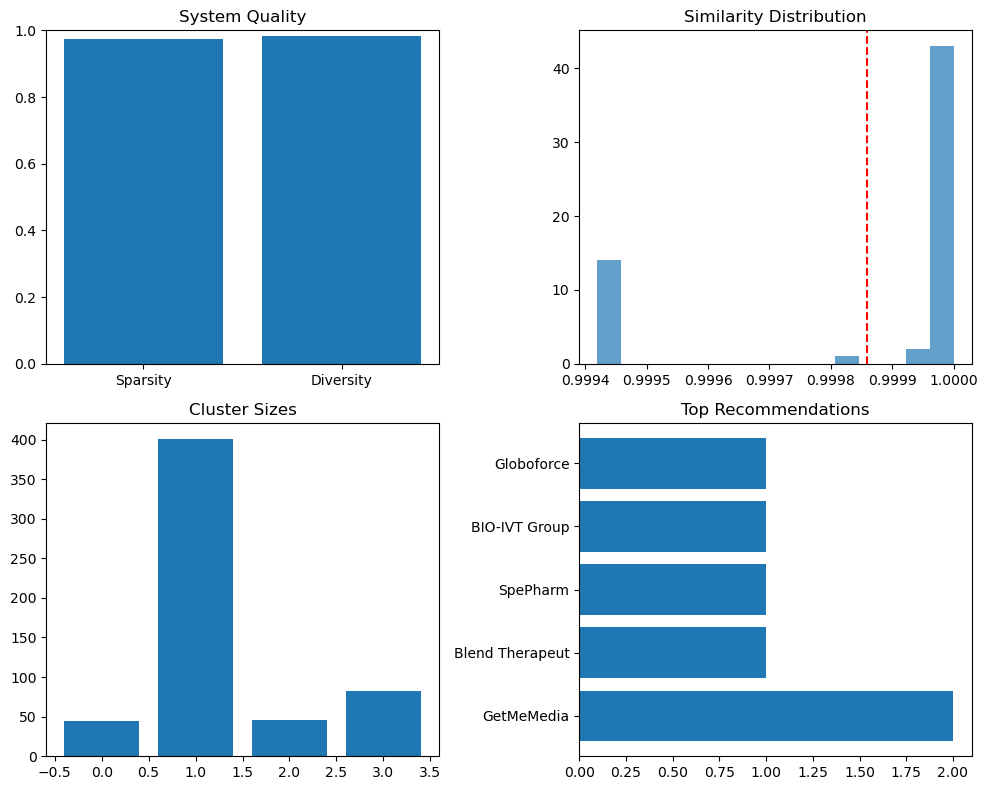

In [85]:
#Model Evaluation
def evaluate_recommender_compact(recommender, sample_investors=3):
    """Complete evaluation with plotting"""
    print("Evaluating Recommendation System")
    
    # TF-IDF Quality Analysis
    tfidf_matrix = recommender.tfidf.transform(recommender.startup_profiles['category_code'])
    sparsity = 1.0 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
    vocab_size = len(recommender.tfidf.vocabulary_)
    
    # Clustering Analysis  
    labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(recommender.startup_features)
    silhouette = silhouette_score(recommender.startup_features, labels)
    
    # Recommendation Analysis
    investors = recommender.investor_profiles['name'].sample(sample_investors).tolist()
    all_recs, all_sims = [], []
    for inv in investors:
        try: 
            recs = recommender.recommend_startups(inv)
            all_recs.extend(recs['Company_name'].tolist())
            all_sims.extend(recs['similarity_score'].tolist())
        except: continue
    
    diversity = len(set(all_recs)) / len(all_recs) if all_recs else 0
    sim_stats = {'mean': np.mean(all_sims), 'std': np.std(all_sims)} if all_sims else {'mean': 0, 'std': 0}
    
    # Results Summary
    results = {'sparsity': sparsity, 'vocab_size': vocab_size, 'silhouette': silhouette, 
               'diversity': diversity, 'sim_mean': sim_stats['mean'], 'sim_std': sim_stats['std']}
    
    print(f" Sparsity: {sparsity:.3f} | Vocab: {vocab_size} | Clustering: {silhouette:.3f}")
    print(f" Diversity: {diversity:.3f} | Similarity: {sim_stats['mean']:.3f}±{sim_stats['std']:.3f}")
    print(f" Top Categories: {list(recommender.tfidf.vocabulary_.keys())[:5]}")
    
    # Compact Visualization (2x2 plots)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))
    ax1.bar(['Sparsity', 'Diversity'], [sparsity, diversity]); ax1.set_title('System Quality'); ax1.set_ylim(0, 1)
    ax2.hist(all_sims, bins=15, alpha=0.7); ax2.set_title('Similarity Distribution'); ax2.axvline(sim_stats['mean'], color='red', linestyle='--')
    cluster_counts = Counter(labels); ax3.bar(range(len(cluster_counts)), list(cluster_counts.values())); ax3.set_title('Cluster Sizes')
    if len(all_recs) > 0: rec_counts = Counter(all_recs).most_common(5); ax4.barh([r[0][:15] for r in rec_counts], [r[1] for r in rec_counts]); ax4.set_title('Top Recommendations')
    plt.tight_layout(); plt.show()
    
    return results

# Usage: results = evaluate_recommender_compact(recommender)

# recommender 
recommender = InvestorStartupRecommender('output3_cleaned.csv')

# run the evaluation
results = evaluate_recommender_compact(recommender)